In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 232s 1us/step


In [4]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [14]:
from tensorflow.keras import models, layers

model = models.Sequential()

# Better practice: define Input layer separately
model.add(layers.Input(shape=(32, 32, 3)))

# Convolution + Pooling layers
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))

# Flatten + Dense layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

# Add dropout to prevent overfitting
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4421 - loss: 1.5260 - val_accuracy: 0.5414 - val_loss: 1.2677
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5874 - loss: 1.1609 - val_accuracy: 0.6194 - val_loss: 1.0802
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6417 - loss: 1.0157 - val_accuracy: 0.6315 - val_loss: 1.0552
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6759 - loss: 0.9236 - val_accuracy: 0.6626 - val_loss: 0.9542
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6977 - loss: 0.8559 - val_accuracy: 0.6869 - val_loss: 0.9067
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7222 - loss: 0.7987 - val_accuracy: 0.6884 - val_loss: 0.9029
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7379 - loss: 0.7504 - val_accuracy: 0.6880 - val_loss: 0.9103
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7486 - loss: 0

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7094 - loss: 0.8637
Test Accuracy: 0.7093999981880188


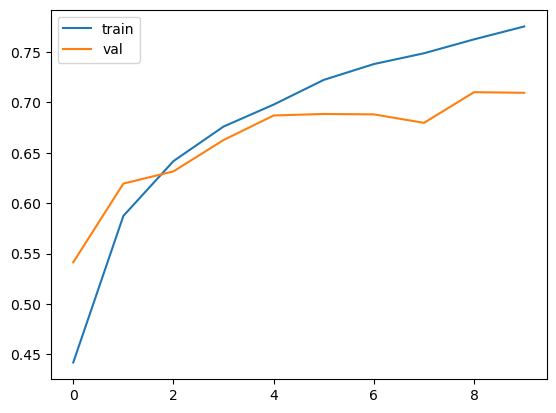

In [9]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [21]:
# Returns list of all weights (including biases)
all_params = model.get_weights()

print("Total parameter arrays:", len(all_params))

Total parameter arrays: 10


In [23]:
for layer in model.layers:
    weights = layer.get_weights()
    
    if weights:  # only layers with parameters
        print(f"\nLayer: {layer.name}")
        print("Weights shape:", weights[0].shape)
        print("Bias shape:", weights[1].shape)


Layer: conv2d_3
Weights shape: (3, 3, 3, 32)
Bias shape: (32,)

Layer: conv2d_4
Weights shape: (3, 3, 32, 64)
Bias shape: (64,)

Layer: conv2d_5
Weights shape: (3, 3, 64, 64)
Bias shape: (64,)

Layer: dense_2
Weights shape: (4096, 64)
Bias shape: (64,)

Layer: dense_3
Weights shape: (64, 10)
Bias shape: (10,)
